In [2]:
import matplotlib.pyplot as plt
!curl -o img.tar.gz https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0110EN-SkillsNetwork/labs/Week1/data/img.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100 50460  100 50460    0     0  23214      0  0:00:02  0:00:02 --:--:-- 23242


In [3]:
!tar -xf img.tar.gz

In [5]:
!curl -o index.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0110EN-SkillsNetwork/labs/Week1/data/index.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
 15 1641k   15  250k    0     0   128k      0  0:00:12  0:00:01  0:00:11  128k
100 1641k  100 1641k    0     0   691k      0  0:00:02  0:00:02 --:--:--  692k


In [6]:
def data_show(data_sample, shape=(28, 28)):
    plt.imshow(data_sample[0].numpy().reshape(shape), cmap='gray')
    plt.title('y = ' + data_sample[1])

In [7]:
import torch
import matplotlib.pylab as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
from matplotlib.pyplot import imshow
from PIL import Image
import pandas as pd
import os

In [8]:
data_name = pd.read_csv("index.csv")
data_name.head()

,category,image
0,Ankle boot,img/fashion0.png
1,T-shirt,img/fashion1.png
2,T-shirt,img/fashion2.png
3,Dress,img/fashion3.png
4,T-shirt,img/fashion4.png


In [9]:
print(f"First file: {data_name.iloc[0, 1]}")

First file: img/fashion0.png


In [10]:
print(f"First category: {data_name.iloc[0, 0]}")

First category: Ankle boot


In [11]:
data_name.shape

(60000, 2)

In [15]:
second_image_path = data_name.iloc[1, 1]
second_image_name = data_name.iloc[1, 0]
second_image_path

'img/fashion1.png'

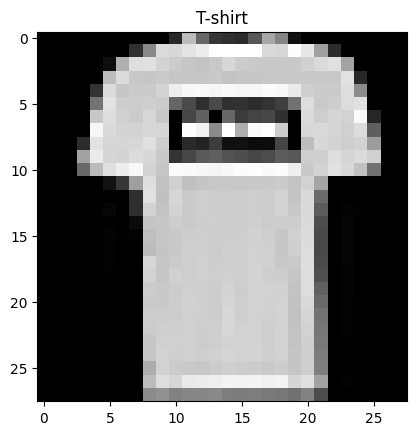

In [26]:
image = Image.open(second_image_path)
plt.imshow(image, cmap='gray',vmin=0, vmax=255 )
plt.title(second_image_name)
plt.show()

In [27]:
class Dataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.transform = transform
        self.data_name = pd.read_csv(csv_file)
        self.len = self.data_name.shape[0]

    def __len__(self):
        return self.len

    def __getitem__(self, index):
        img_name = self.data_name.iloc[index, 1]
        image = Image.open(img_name)
        y = self.data_name.iloc[index, 0]

        if self.transform:
            image = self.transform(image)

        return image, y

In [28]:
dataset = Dataset(csv_file='index.csv')

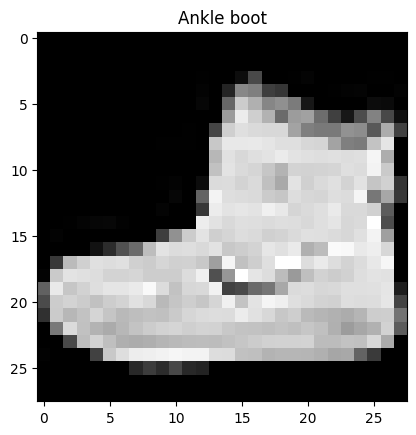

In [29]:
image = dataset[0][0]
y = dataset[0][1]

plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title(y)
plt.show()

In [30]:
y

'Ankle boot'

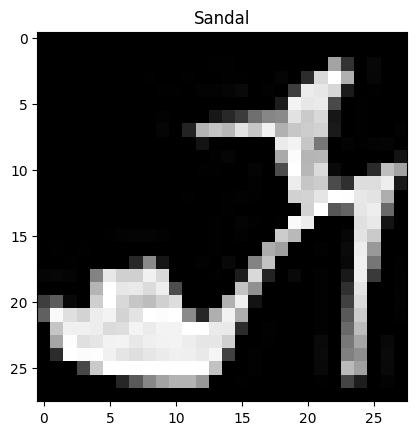

In [31]:
image=dataset[9][0]
y=dataset[9][1]

plt.imshow(image,cmap='gray', vmin=0, vmax=255)
plt.title(y)
plt.show()

In [32]:
from torchvision import transforms

croptensor_data_transform = transforms.Compose([transforms.CenterCrop(20), transforms.ToTensor()])
dataset = Dataset(csv_file='index.csv', transform=croptensor_data_transform)
print(dataset[0][0].shape)

torch.Size([1, 20, 20])


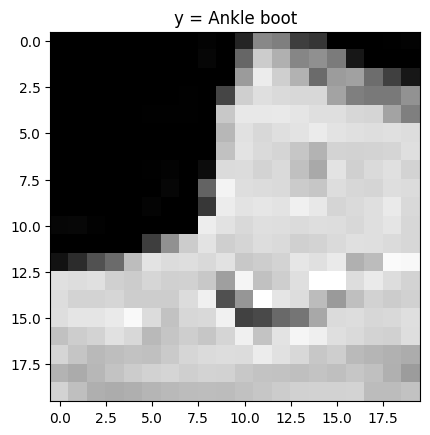

In [34]:
data_show(dataset[0], shape=(20,20))

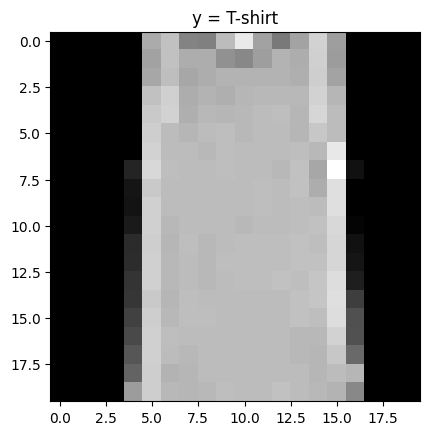

In [35]:
data_show(dataset[2], shape=(20,20))

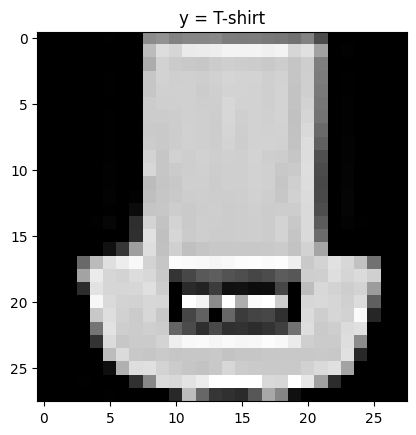

In [38]:
fliptensor_data_transform = transforms.Compose([transforms.RandomVerticalFlip(p=1), transforms.ToTensor()])
dataset = Dataset(csv_file='index.csv', transform=fliptensor_data_transform)
data_show(dataset[1])

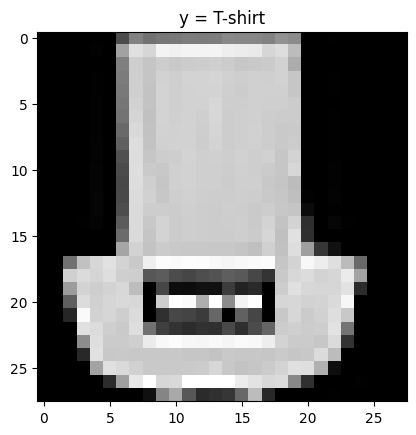

In [40]:
my_data_transform = transforms.Compose([transforms.RandomVerticalFlip(p = 1), transforms.RandomHorizontalFlip(p = 1), transforms.ToTensor()])
dataset = Dataset(csv_file='index.csv', transform=my_data_transform)
data_show(dataset[1])